In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
df = pd.read_csv('../seminars/S06-hw-dataset-01.csv')
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
df.head()


Размер датасета: (12000, 30)

Первые 5 строк:


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [ ]:

print("Пропуски в данных:")
print(df.isnull().sum().sum())
print("\nБазовые статистики:")
df.describe()


Пропуски в данных:
0

Базовые статистики:


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


Распределение таргета:
Класс 0: 0.677 (8119 примеров)
Класс 1: 0.323 (3881 примеров)


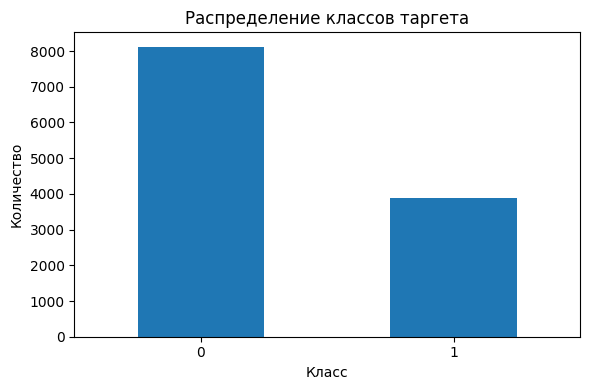

In [ ]:
target_counts = df['target'].value_counts()
target_dist = df['target'].value_counts(normalize=True).sort_index()
print("Распределение таргета:")
for class_label in sorted(target_dist.index):
    print(f"Класс {class_label}: {target_dist[class_label]:.3f} ({target_counts[class_label]} примеров)")

plt.figure(figsize=(6, 4))
target_counts.sort_index().plot(kind='bar')
plt.title('Распределение классов таргета')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=150)
plt.show()


In [ ]:
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print(f"Признаков: {X.shape[1]}")
print(f"Примеров: {X.shape[0]}")
print(f"\nСписок признаков:\n{X.columns.tolist()}")


Признаков: 28
Примеров: 12000

Список признаков:
['num01', 'num02', 'num03', 'num04', 'num05', 'num06', 'num07', 'num08', 'num09', 'num10', 'num11', 'num12', 'num13', 'num14', 'num15', 'num16', 'num17', 'num18', 'num19', 'num20', 'num21', 'num22', 'num23', 'num24', 'cat_contract', 'cat_region', 'cat_payment', 'tenure_months']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train: {X_train.shape[0]} примеров")
print(f"Test: {X_test.shape[0]} примеров")
print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))

# Фиксированный random_state обеспечивает воспроизводимость результатов. Статификация гарантирует, что распределение между train и test будет одинаковым и у нас не возникнет проблем с несбалансированными данными


Train: 9600 примеров
Test: 2400 примеров

Распределение классов в train:
target
0    0.676562
1    0.323437
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.676667
1    0.323333
Name: proportion, dtype: float64


In [ ]:
results = {}

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_roc_auc = None

results['DummyClassifier'] = {
    'accuracy': dummy_accuracy,
    'f1': dummy_f1,
    'roc_auc': dummy_roc_auc
}

print("DummyClassifier (most_frequent):")
print(f"  Accuracy: {dummy_accuracy:.4f}")
print(f"  F1: {dummy_f1:.4f}")
print(f"  ROC-AUC: N/A (dummy classifier)")


DummyClassifier (most_frequent):
  Accuracy: 0.6767
  F1: 0.0000
  ROC-AUC: N/A (dummy classifier)


In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_proba_lr)

results['LogisticRegression'] = {
    'accuracy': lr_accuracy,
    'f1': lr_f1,
    'roc_auc': lr_roc_auc
}

print("LogisticRegression:")
print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  F1: {lr_f1:.4f}")
print(f"  ROC-AUC: {lr_roc_auc:.4f}")


LogisticRegression:
  Accuracy: 0.8275
  F1: 0.7076
  ROC-AUC: 0.8747


In [ ]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10]
}

print("Подбор гиперпараметров для DecisionTreeClassifier...")
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_grid = GridSearchCV(
    dt_clf, 
    dt_param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Лучшие параметры для DecisionTreeClassifier:")
print(dt_grid.best_params_)
print(f"Лучший CV score (ROC-AUC): {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_proba_dt = dt_best.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_proba_dt)

results['DecisionTreeClassifier'] = {
    'accuracy': dt_accuracy,
    'f1': dt_f1,
    'roc_auc': dt_roc_auc,
    'best_params': dt_grid.best_params_,
    'cv_score': dt_grid.best_score_
}

print(f"\nTest метрики:")
print(f"  Accuracy: {dt_accuracy:.4f}")
print(f"  F1: {dt_f1:.4f}")
print(f"  ROC-AUC: {dt_roc_auc:.4f}")


Лучшие параметры для DecisionTreeClassifier:
{'max_depth': 10, 'min_samples_leaf': 10}
Лучший CV score (ROC-AUC): 0.9076

Test метрики:
  Accuracy: 0.8767
  F1: 0.8000
  ROC-AUC: 0.9069


In [ ]:
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

print("Подбор гиперпараметров для RandomForestClassifier...")
print("Это может занять несколько минут...\n")

rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_clf,
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1  
)

rf_grid.fit(X_train, y_train)

print("Лучшие параметры для RandomForestClassifier:")
print(rf_grid.best_params_)
print(f"Лучший CV score (ROC-AUC): {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

results['RandomForestClassifier'] = {
    'accuracy': rf_accuracy,
    'f1': rf_f1,
    'roc_auc': rf_roc_auc,
    'best_params': rf_grid.best_params_,
    'cv_score': rf_grid.best_score_
}

print(f"\nTest метрики:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  F1: {rf_f1:.4f}")
print(f"  ROC-AUC: {rf_roc_auc:.4f}")


Лучшие параметры для RandomForestClassifier:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Лучший CV score (ROC-AUC): 0.9685

Test метрики:
  Accuracy: 0.9246
  F1: 0.8775
  ROC-AUC: 0.9648


In [ ]:
gb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'min_samples_leaf': [1, 2]
}

print("Подбор гиперпараметров для GradientBoostingClassifier...")
print(f"Количество комбинаций: {len(gb_param_grid['n_estimators']) * len(gb_param_grid['max_depth']) * len(gb_param_grid['learning_rate']) * len(gb_param_grid['min_samples_leaf'])} комбинаций")
print("Это может занять несколько минут...\n")

gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_grid = GridSearchCV(
    gb_clf,
    gb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1 
)

gb_grid.fit(X_train, y_train)

print("Лучшие параметры для GradientBoostingClassifier:")
print(gb_grid.best_params_)
print(f"Лучший CV score (ROC-AUC): {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test)
y_proba_gb = gb_best.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_proba_gb)

results['GradientBoostingClassifier'] = {
    'accuracy': gb_accuracy,
    'f1': gb_f1,
    'roc_auc': gb_roc_auc,
    'best_params': gb_grid.best_params_,
    'cv_score': gb_grid.best_score_
}

print(f"\nTest метрики:")
print(f"  Accuracy: {gb_accuracy:.4f}")
print(f"  F1: {gb_f1:.4f}")
print(f"  ROC-AUC: {gb_roc_auc:.4f}")


Лучшие параметры для GradientBoostingClassifier:
{'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}
Лучший CV score (ROC-AUC): 0.9729

Test метрики:
  Accuracy: 0.9296
  F1: 0.8873
  ROC-AUC: 0.9686


In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.drop('best_params', axis=1, errors='ignore')
results_df = results_df.drop('cv_score', axis=1, errors='ignore')
results_df['roc_auc'] = results_df['roc_auc'].fillna('N/A')

print("Сравнение метрик на test set:")
print(results_df.to_string())

results_to_save = {}
for model_name, metrics in results.items():
    results_to_save[model_name] = {
        'accuracy': float(metrics['accuracy']),
        'f1': float(metrics['f1']),
        'roc_auc': float(metrics['roc_auc']) if metrics['roc_auc'] is not None else None
    }
    if 'best_params' in metrics:
        results_to_save[model_name]['best_params'] = {str(k): str(v) for k, v in metrics['best_params'].items()}
    if 'cv_score' in metrics:
        results_to_save[model_name]['cv_score'] = float(metrics['cv_score'])

with open('artifacts/metrics_test.json', 'w', encoding='utf-8') as f:
    json.dump(results_to_save, f, indent=2, ensure_ascii=False)


Сравнение метрик на test set:
                            accuracy        f1   roc_auc
DummyClassifier             0.676667       0.0       N/A
LogisticRegression            0.8275  0.707627  0.874691
DecisionTreeClassifier      0.876667       0.8  0.906921
RandomForestClassifier      0.924583  0.877454  0.964817
GradientBoostingClassifier  0.929583  0.887258   0.96855


In [ ]:
search_summaries = {}
for model_name in ['DecisionTreeClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier']:
    if model_name in results and 'best_params' in results[model_name]:
        search_summaries[model_name] = {
            'best_params': {str(k): str(v) for k, v in results[model_name]['best_params'].items()},
            'cv_score': float(results[model_name]['cv_score'])
        }

with open('artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

print("Поиск гиперпараметров (CV scores):")
for model, summary in search_summaries.items():
    print(f"\n{model}:")
    print(f"  Параметры: {summary['best_params']}")
    print(f"  CV ROC-AUC: {summary['cv_score']:.4f}")


Поиск гиперпараметров (CV scores):

DecisionTreeClassifier:
  Параметры: {'max_depth': '10', 'min_samples_leaf': '10'}
  CV ROC-AUC: 0.9076

RandomForestClassifier:
  Параметры: {'max_depth': 'None', 'max_features': 'sqrt', 'min_samples_leaf': '2', 'n_estimators': '100'}
  CV ROC-AUC: 0.9685

GradientBoostingClassifier:
  Параметры: {'learning_rate': '0.2', 'max_depth': '7', 'min_samples_leaf': '5', 'n_estimators': '100'}
  CV ROC-AUC: 0.9729


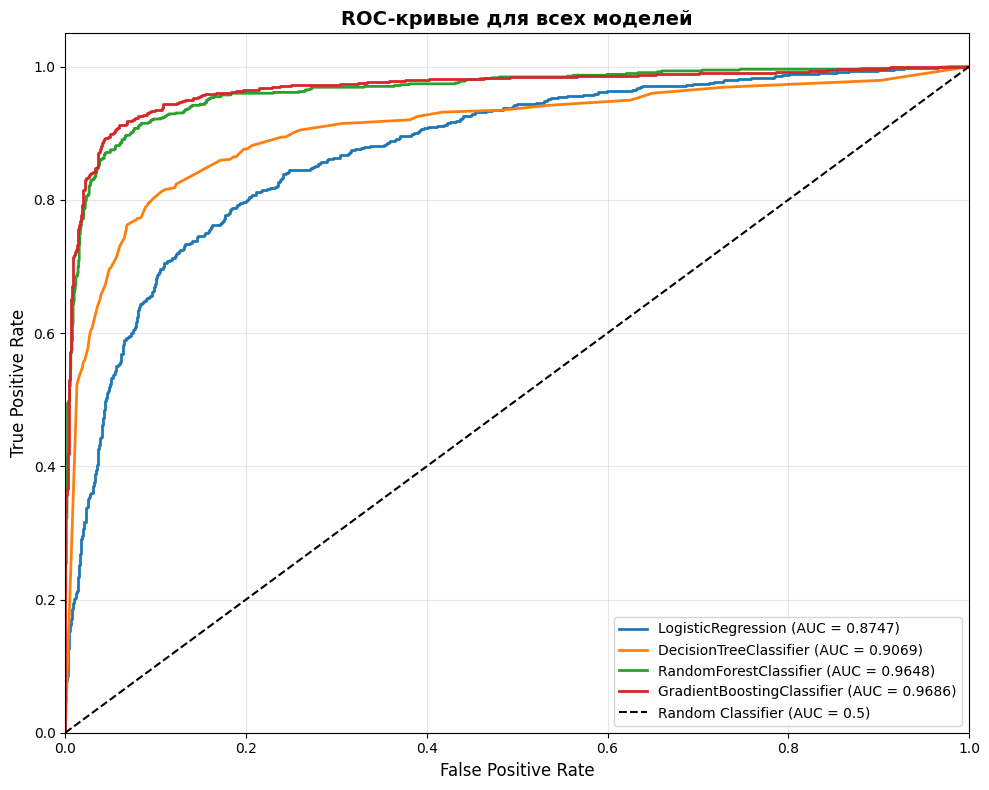

In [ ]:
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC = {lr_roc_auc:.4f})', linewidth=2)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'DecisionTreeClassifier (AUC = {dt_roc_auc:.4f})', linewidth=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RandomForestClassifier (AUC = {rf_roc_auc:.4f})', linewidth=2)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
plt.plot(fpr_gb, tpr_gb, label=f'GradientBoostingClassifier (AUC = {gb_roc_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложноположительных (False Positive Rate)', fontsize=12)
plt.ylabel('Доля истинноположительных (True Positive Rate)', fontsize=12)
plt.title('ROC-кривые для всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Лучшая модель по ROC-AUC: GradientBoostingClassifier
ROC-AUC: 0.9686


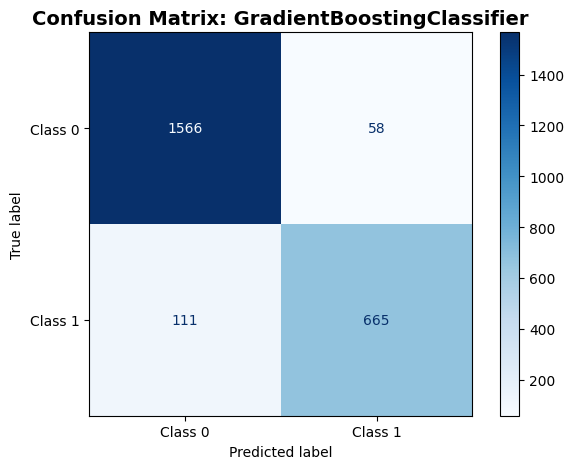

In [ ]:
best_model_name = max(
    [k for k in results.keys() if results[k]['roc_auc'] is not None],
    key=lambda k: results[k]['roc_auc']
)

print(f"Лучшая модель по ROC-AUC: {best_model_name}")
print(f"ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

if best_model_name == 'LogisticRegression':
    y_pred_best = y_pred_lr
    best_model = lr_pipeline
elif best_model_name == 'DecisionTreeClassifier':
    y_pred_best = y_pred_dt
    best_model = dt_best
elif best_model_name == 'RandomForestClassifier':
    y_pred_best = y_pred_rf
    best_model = rf_best
elif best_model_name == 'GradientBoostingClassifier':
    y_pred_best = y_pred_gb
    best_model = gb_best

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Класс 0', 'Класс 1'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Матрица ошибок: {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Top-15 признаков по важности:
feature  importance_mean  importance_std
  num19         0.111833        0.005035
  num18         0.097875        0.005619
  num07         0.057292        0.002246
  num04         0.025458        0.003214
  num24         0.019375        0.003600
  num20         0.015667        0.003102
  num14         0.015583        0.002043
  num01         0.014250        0.002614
  num16         0.012542        0.002810
  num22         0.007042        0.001350
  num08         0.007042        0.002510
  num21         0.006042        0.001253
  num17         0.003917        0.001320
  num02         0.002208        0.001845
  num12         0.000958        0.000619


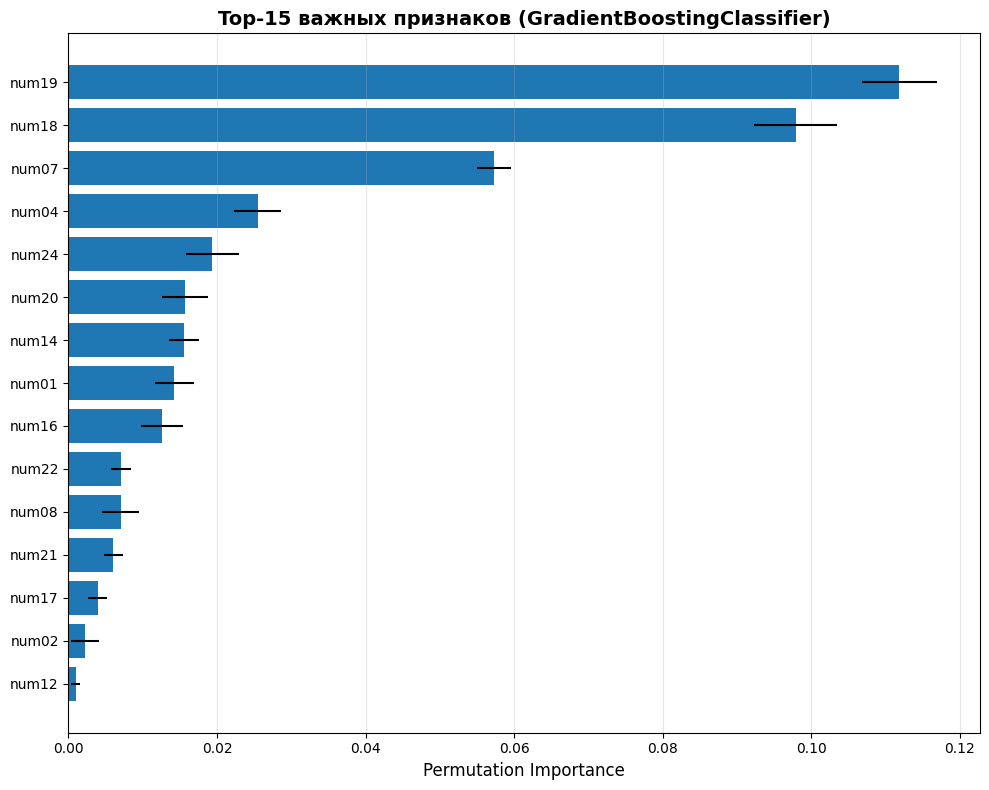

In [ ]:
perm_importance = permutation_importance(
    best_model, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("Top-15 признаков по важности:")
print(importance_df.head(15).to_string(index=False))

top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), top_features['importance_mean'][::-1], xerr=top_features['importance_std'][::-1])
plt.yticks(range(top_n), top_features['feature'][::-1])
plt.xlabel('Важность признака (Permutation Importance)', fontsize=12)
plt.title(f'Top-{top_n} важных признаков ({best_model_name})', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('artifacts/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
joblib.dump(best_model, 'artifacts/best_model.joblib')

best_model_meta = {
    'model_name': best_model_name,
    'accuracy': float(results[best_model_name]['accuracy']),
    'f1': float(results[best_model_name]['f1']),
    'roc_auc': float(results[best_model_name]['roc_auc']),
    'best_params': {str(k): str(v) for k, v in results[best_model_name].get('best_params', {}).items()},
    'cv_score': float(results[best_model_name].get('cv_score', 0)) if 'cv_score' in results[best_model_name] else None
}

with open('artifacts/best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

print("Лучшая модель сохранена:")
print(json.dumps(best_model_meta, indent=2, ensure_ascii=False))


Лучшая модель сохранена:
{
  "model_name": "GradientBoostingClassifier",
  "accuracy": 0.9295833333333333,
  "f1": 0.8872581721147431,
  "roc_auc": 0.9685500355492357,
  "best_params": {
    "learning_rate": "0.2",
    "max_depth": "7",
    "min_samples_leaf": "5",
    "n_estimators": "100"
  },
  "cv_score": 0.9728719850151052
}
